生成实验图表...

✓ 已保存: experiment1_8421.png
✓ 已保存: experiment2_1111.png


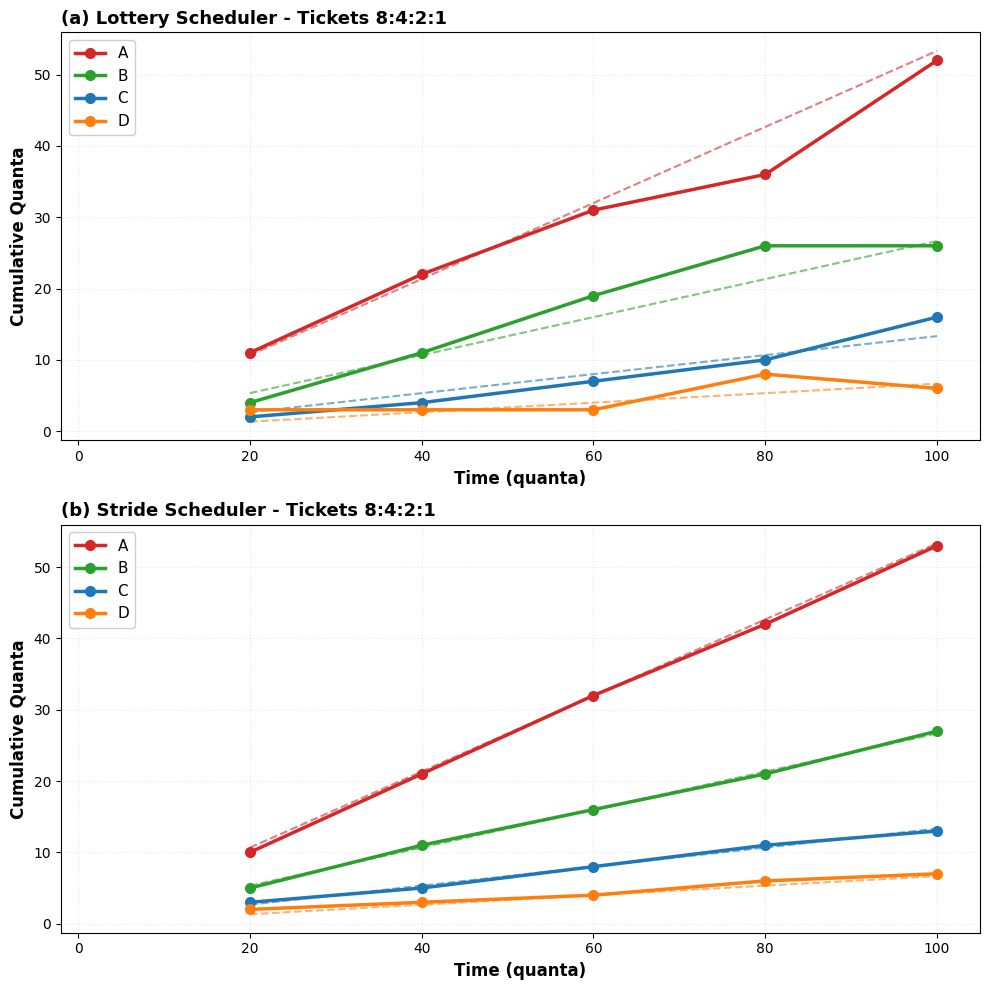

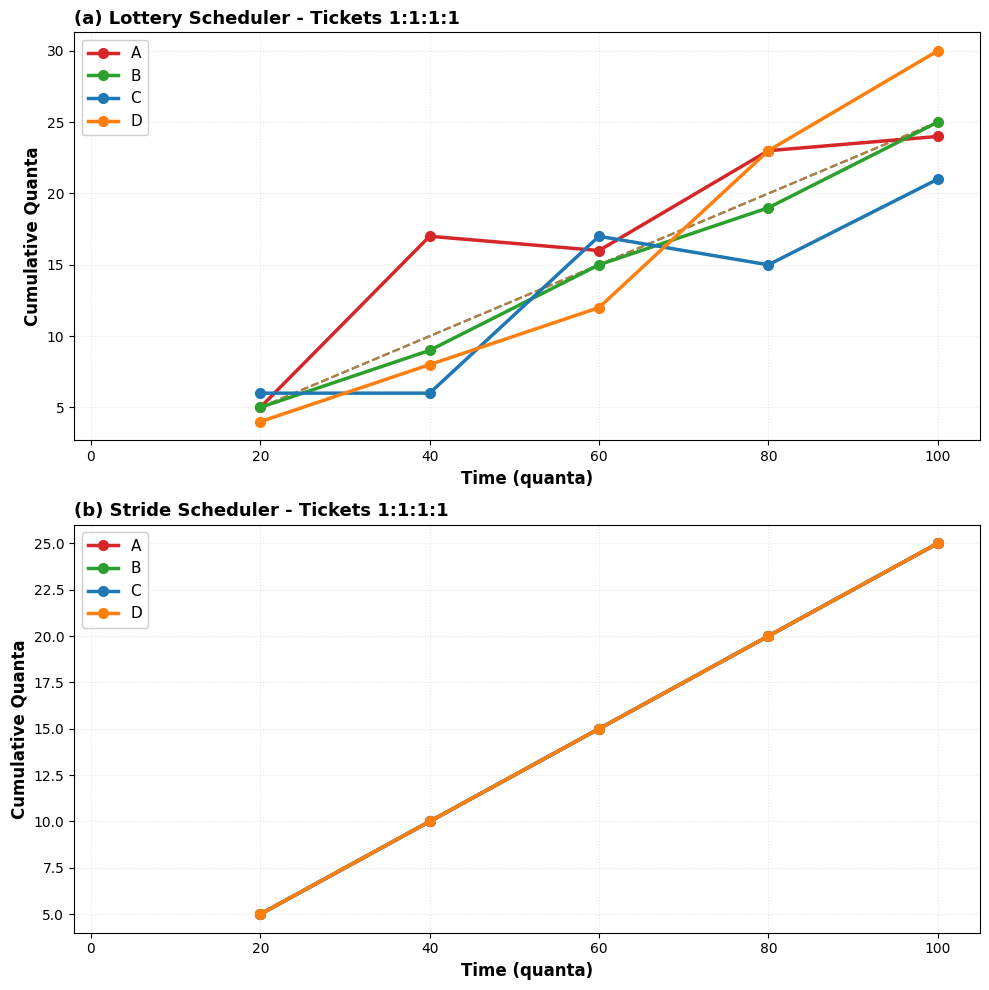


实验数据分析

【实验1: 8:4:2:1 配置】
----------------------------------------------------------------------
理想分配比例: A=53.3%, B=26.7%, C=13.3%, D=6.7%

LOTTERY调度器 (在100 ticks时):
  A: 52 ticks (52.0%) | 理想: 53.3 | 误差: 2.5%
  B: 26 ticks (26.0%) | 理想: 26.7 | 误差: 2.5%
  C: 16 ticks (16.0%) | 理想: 13.3 | 误差: 20.0%
  D: 6 ticks (6.0%) | 理想: 6.7 | 误差: 10.0%

STRIDE调度器 (在100 ticks时):
  A: 53 ticks (53.0%) | 理想: 53.3 | 误差: 0.6%
  B: 27 ticks (27.0%) | 理想: 26.7 | 误差: 1.3%
  C: 13 ticks (13.0%) | 理想: 13.3 | 误差: 2.5%
  D: 7 ticks (7.0%) | 理想: 6.7 | 误差: 5.0%

【实验2: 1:1:1:1 配置】
----------------------------------------------------------------------
理想分配比例: 各进程 25%

LOTTERY调度器 (在100 ticks时):
  A: 24 ticks (24.0%) | 理想: 25.0 | 误差: 4.0%
  B: 25 ticks (25.0%) | 理想: 25.0 | 误差: 0.0%
  C: 21 ticks (21.0%) | 理想: 25.0 | 误差: 16.0%
  D: 30 ticks (30.0%) | 理想: 25.0 | 误差: 20.0%

STRIDE调度器 (在100 ticks时):
  A: 25 ticks (25.0%) | 理想: 25.0 | 误差: 0.0%
  B: 25 ticks (25.0%) | 理想: 25.0 | 误差: 0.0%
  C: 25 ticks (25.0%) | 理想: 25.0 |

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 提取数据
time_points = [20, 40, 60, 80, 100]

# LOTTERY 8:4:2:1
lottery_exp1 = {
    'A': [11, 22, 31, 36, 52],
    'B': [4, 11, 19, 26, 26],
    'C': [2, 4, 7, 10, 16],
    'D': [3, 3, 3, 8, 6],
}

# STRIDE 8:4:2:1
stride_exp1 = {
    'A': [10, 21, 32, 42, 53],
    'B': [5, 11, 16, 21, 27],
    'C': [3, 5, 8, 11, 13],
    'D': [2, 3, 4, 6, 7],
}

# LOTTERY 1:1:1:1
lottery_exp2 = {
    'A': [5, 17, 16, 23, 24],
    'B': [5, 9, 15, 19, 25],
    'C': [6, 6, 17, 15, 21],
    'D': [4, 8, 12, 23, 30],
}

# STRIDE 1:1:1:1
stride_exp2 = {
    'A': [5, 10, 15, 20, 25],
    'B': [5, 10, 15, 20, 25],
    'C': [5, 10, 15, 20, 25],
    'D': [5, 10, 15, 20, 25],
}

# 理想分配
def calculate_ideal(tickets, time_points):
    total = sum(tickets)
    labels = ['A', 'B', 'C', 'D']
    ideal = {label: [] for label in labels}
    for label, ticket in zip(labels, tickets):
        ideal[label] = [t * ticket / total for t in time_points]
    return ideal

ideal_exp1 = calculate_ideal([8, 4, 2, 1], time_points)
ideal_exp2 = calculate_ideal([1, 1, 1, 1], time_points)

# 绘图函数
def plot_experiment(lottery_data, stride_data, ideal_data, time_points, config, filename):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    
    colors = {'A': '#D62728', 'B': '#2CA02C', 'C': '#1F77B4', 'D': '#FF7F0E'}
    labels = ['A', 'B', 'C', 'D']
    
    # Lottery
    for label in labels:
        ax1.plot(time_points, lottery_data[label], 
                color=colors[label], marker='o', linestyle='-', 
                linewidth=2.5, markersize=7, label=label, zorder=3)
        ax1.plot(time_points, ideal_data[label], 
                color=colors[label], linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
    
    ax1.set_xlabel('Time (quanta)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Cumulative Quanta', fontsize=12, fontweight='bold')
    ax1.set_title(f'(a) Lottery Scheduler - {config}', fontsize=13, fontweight='bold', loc='left')
    ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax1.set_xlim(-2, 105)
    
    # Stride
    for label in labels:
        ax2.plot(time_points, stride_data[label], 
                color=colors[label], marker='o', linestyle='-', 
                linewidth=2.5, markersize=7, label=label, zorder=3)
        ax2.plot(time_points, ideal_data[label], 
                color=colors[label], linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
    
    ax2.set_xlabel('Time (quanta)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Cumulative Quanta', fontsize=12, fontweight='bold')
    ax2.set_title(f'(b) Stride Scheduler - {config}', fontsize=13, fontweight='bold', loc='left')
    ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    ax2.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax2.set_xlim(-2, 105)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ 已保存: {filename}")

# 生成图表
print("生成实验图表...\n")
plot_experiment(lottery_exp1, stride_exp1, ideal_exp1, time_points, 
               'Tickets 8:4:2:1', 'experiment1_8421.png')
plot_experiment(lottery_exp2, stride_exp2, ideal_exp2, time_points, 
               'Tickets 1:1:1:1', 'experiment2_1111.png')

plt.show()

# 分析
print("\n" + "="*70)
print("实验数据分析")
print("="*70)

print("\n【实验1: 8:4:2:1 配置】")
print("-"*70)
print("理想分配比例: A=53.3%, B=26.7%, C=13.3%, D=6.7%")

print("\nLOTTERY调度器 (在100 ticks时):")
lottery_total = sum([lottery_exp1[l][-1] for l in ['A', 'B', 'C', 'D']])
for label in ['A', 'B', 'C', 'D']:
    actual = lottery_exp1[label][-1]
    ideal = ideal_exp1[label][-1]
    pct = (actual / lottery_total) * 100
    error = abs(pct/100 - [8/15, 4/15, 2/15, 1/15][['A','B','C','D'].index(label)]) / [8/15, 4/15, 2/15, 1/15][['A','B','C','D'].index(label)] * 100
    print(f"  {label}: {actual:.0f} ticks ({pct:.1f}%) | 理想: {ideal:.1f} | 误差: {error:.1f}%")

print("\nSTRIDE调度器 (在100 ticks时):")
stride_total = sum([stride_exp1[l][-1] for l in ['A', 'B', 'C', 'D']])
for label in ['A', 'B', 'C', 'D']:
    actual = stride_exp1[label][-1]
    ideal = ideal_exp1[label][-1]
    pct = (actual / stride_total) * 100
    error = abs(pct/100 - [8/15, 4/15, 2/15, 1/15][['A','B','C','D'].index(label)]) / [8/15, 4/15, 2/15, 1/15][['A','B','C','D'].index(label)] * 100
    print(f"  {label}: {actual:.0f} ticks ({pct:.1f}%) | 理想: {ideal:.1f} | 误差: {error:.1f}%")

print("\n【实验2: 1:1:1:1 配置】")
print("-"*70)
print("理想分配比例: 各进程 25%")

print("\nLOTTERY调度器 (在100 ticks时):")
lottery_total2 = sum([lottery_exp2[l][-1] for l in ['A', 'B', 'C', 'D']])
for label in ['A', 'B', 'C', 'D']:
    actual = lottery_exp2[label][-1]
    ideal = ideal_exp2[label][-1]
    pct = (actual / lottery_total2) * 100
    error = abs(pct - 25) / 25 * 100
    print(f"  {label}: {actual:.0f} ticks ({pct:.1f}%) | 理想: {ideal:.1f} | 误差: {error:.1f}%")

print("\nSTRIDE调度器 (在100 ticks时):")
stride_total2 = sum([stride_exp2[l][-1] for l in ['A', 'B', 'C', 'D']])
for label in ['A', 'B', 'C', 'D']:
    actual = stride_exp2[label][-1]
    ideal = ideal_exp2[label][-1]
    pct = (actual / stride_total2) * 100
    error = abs(pct - 25) / 25 * 100
    print(f"  {label}: {actual:.0f} ticks ({pct:.1f}%) | 理想: {ideal:.1f} | 误差: {error:.1f}%")

print("\n" + "="*70)
print("✓ 图表已生成完成！")
print("="*70)